In [1]:
from mpl_toolkits import mplot3d
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.cm as cm
import matplotlib
import math
import seaborn as sns
import pandas as pd
from sympy import *
from sympy import Symbol, solveset, S, erf, log, sqrt
init_printing(use_unicode=True)

In [2]:
def U_D(gamma_1,gamma_0,C_1,r,delta):
    return (1-delta)*np.dot(r,gamma_1) - np.dot(np.dot(np.subtract(gamma_1,gamma_0),C_1),np.subtract(gamma_1,gamma_0))

#U_D = term0 * alpha_0 + termA*beta_0^2 + termB&beta_0 + termC
def get_UD_zero_levelset_terms(C_1,r,delta,theta):
    term0 = (1-delta)*r[0]
    termC = ((1-delta)**2/(4*C_1[0,0]) 
             + (1-delta)*r[1]*theta 
             - (C_1[0,1]*(1-delta)*r[0]*theta/C_1[0,0]) 
             + C_1[0,1]**2 * theta**2 / C_1[0,0]
             - C_1[1,1]*theta**2
            )
    termB = (C_1[0,1]*(1-delta)*r[0] / C_1[0,0]
             - 2*C_1[0,1]**2 * theta / C_1[0,0]
             + 2*C_1[1,1]*theta
            )
    termA = (C_1[0,1]**2 / C_1[0,0]
             - C_1[1,1]
            )
    return term0,termA,termB,termC

def D_strategy(gamma_0,C_1,r,delta,theta):
    if sum(np.equal(gamma_0,[-.1,-.1]))==2:
        return np.array([-.1,-.1]),-.1,"abstain"
    #Abstain condition
    alpha_0 = gamma_0[0]
    beta_0 = gamma_0[1]
    #This is the version without cross-terms
    #abstain_quadratic_A = -C_1[1,1]
    #abstain_quadratic_B = (C_1[0,1]*(1-delta)*r[0]/C_1[0,0]) + 2*theta*C_1[1,1]
    #abstain_quadratic_C = ((1-delta)**2 * r[0]**2 / (4*C_1[0,0])) + (1-delta)*r[1]*theta - (C_1[0,1]*(1-delta)*r[0]*theta/C_1[0,0])-C_1[1,1]*theta**2
    #if 0 > ((1-delta)*r[0])*alpha_0 + abstain_quadratic_A*beta_0**2 + abstain_quadratic_B*beta_0 + abstain_quadratic_C:
    #    return [-.1,-.1],"abstain",-0.1
    #term0,termA,termB,termC = get_UD_zero_levelset_terms(C_1,r,delta,theta)
    #if 0 > term0*alpha_0 + termA*beta_0**2 + termB*beta_0 + termC:
    #    return [-.1,-.1],-0.1,"abstain"
    #REMOVING THIS
    
    #Closed-form solution
    gamma_candidate_1 = gamma_0 + 0.5 * (1-delta) * np.dot(np.linalg.inv(C_1),r)
    gamma_candidate_2 = np.array([alpha_0,np.max([beta_0+(1-delta)*r[1]/(2*C_1[1,1]),theta])]) #can likely remove the np.max() and theta option from this
    #Making a slight change here to account for cross-terms:
    gamma_candidate_3 = np.array([np.max([alpha_0,
                                          alpha_0+(1-delta)*r[0]/(2*C_1[0,0]) - (C_1[0,1]/C_1[0,0])*(theta-beta_0)]),
                                  np.max([beta_0,theta])
                                 ])
    
    #Omit unconstrained candidate if it is infeasible
    #print([gamma_candidate_1,gamma_candidate_2,gamma_candidate_3])
    if gamma_candidate_1[0]<alpha_0 or gamma_candidate_1[1]<np.max([beta_0,theta]):
        candidates = [gamma_candidate_2,gamma_candidate_3]
        strategy_list = ['constrained $\\alpha_1=\\alpha_0$','constrained $\\beta_1=max(\\beta_0,\\theta)$']
    else:
        candidates = [gamma_candidate_1,gamma_candidate_2,gamma_candidate_3]
        strategy_list = ['unconstrained', 'constrained $\\alpha_1=\\alpha_0$','constrained $\\beta_1=max(\\beta_0,\\theta)$']
        
    #print(candidates)
    #Strategy list for explaining remaining candidates
    strategies = [strategy_list[i] for i in range(len(candidates))]
    
    #Evaluate utilities for remaining candidates
    utilities = [U_D(candidates[i],gamma_0,C_1,r,delta) for i in range(len(candidates))]
    index_choice = np.argmax(utilities)
    
    if utilities[index_choice]<0:
        return [-.1,-.1],-0.1,"abstain"
    
    return candidates[index_choice], utilities[index_choice], strategies[index_choice]
    
def U_G(gamma_0,C_0,C_1,r,delta,theta):
    return delta*np.dot(r,D_strategy(gamma_0,C_1,r,delta,theta)[0]) - np.dot(np.dot(gamma_0,C_0),gamma_0)

def get_candidates(C_0,C_1,delta,r,theta,thetaG,epsilon=0.000001):
    a, b, l = symbols('a b l',real=True)
    C_0_rat = np.array([[Rational(C_0[0,0]),Rational(C_0[0,1])],[Rational(C_0[1,0]),Rational(C_0[1,1])]])
    C_1_rat = np.array([[Rational(C_1[0,0]),Rational(C_1[0,1])],[Rational(C_1[1,0]),Rational(C_1[1,1])]])
    delta_rat = Rational(delta)#0.5
    theta_rat = Rational(theta)
    thetaG_rat = Rational(thetaG)
    r_rat = np.array([Rational(r[0]),Rational(r[1])])
    equation_1 = delta_rat*r_rat[0] - 2*C_0_rat[0,0]*a - 2*C_0_rat[0,1]*b - l*(1-delta_rat)*r_rat[0]
    equation_2 = (delta_rat*C_1_rat[0,1]*r_rat[0]/C_1_rat[0,0]) - 2*C_0_rat[1,1]*b - 2*C_0_rat[0,1]*a - l*(C_1_rat[0,1]*(1-delta_rat)*r_rat[0]/C_1_rat[0,0] - 2*C_1_rat[0,1]**2 * theta_rat/C_1_rat[0,0] + 2*C_1_rat[1,1]*theta_rat + 2*(C_1_rat[0,1]/C_1_rat[0,0]-C_1_rat[1,1])*b)
    term0,termA,termB,termC = get_UD_zero_levelset_terms(C_1_rat,r_rat,delta_rat,theta_rat)
    equation_3 = term0*a + termA*b**2 + termB*b + termC
    raw_results = solve([equation_1,equation_2,equation_3],[a,b,l],domain=S.Reals)#nonlinsolve([equation_1,equation_2,equation_3],[a,b,l],domain=S.Reals)
    raw_results = list(raw_results)
    #print(Float(raw_results,10))
    #print(np.array(raw_results).shape)
    #print(raw_results[0][0])
    results = []
    for i in range(len(raw_results)):
        if isinstance(raw_results[i][0], complex) or isinstance(raw_results[i][1], complex):
            continue
        if ("I" in str(raw_results[i][0]))or("I" in str(raw_results[i][1])):
            continue
        #if N(raw_results[i][0])>1000 or N(raw_results[i][1])>1000:
        #    print("Very large number.")
        #    continue
        results = results + [np.array([N(raw_results[i][j])+epsilon for j in range(2)])]#[np.add(raw_results[i][:2],epsilon)]#[np.array([N(raw_results[i][j])+epsilon for j in range(2)])]
    #results = [np.add(raw_results[i][:2],epsilon) for i in range(len(raw_results))]
    return results

def G_strategy(C_0,C_1,r,delta,theta,thetaG,epsilon=0.000001):
    candidate_1 = 0.5*delta*np.dot(np.linalg.inv(C_0),r)
    candidate_2 = np.array([0,np.max([delta*r[1]/(2*C_0[1,1]),thetaG])])
    candidate_3 = np.array([np.max([0,delta*r[0]/(2*C_0[0,0]) - (C_0[0,1]/C_0[0,0])*thetaG]),thetaG])
    
    term0,termA,termB,termC = get_UD_zero_levelset_terms(C_1,r,delta,theta)
    candidate_5 = [(-1/term0)*(termA*thetaG**2 + termB*thetaG + termC)+epsilon,thetaG+epsilon]
    candidate_6_beta_options = np.real(np.roots([termA,termB,termC]))
    candidate_6_1 = np.array([0+epsilon,candidate_6_beta_options[0]+epsilon])
    candidate_6_2 = np.array([0+epsilon,candidate_6_beta_options[1]+epsilon])
    candidate_7 = np.array([0,thetaG])

    candidate_4_candidates = get_candidates(C_0,C_1,delta,r,theta,thetaG)
    
    candidates_all = [candidate_1, candidate_2,candidate_3,candidate_5,candidate_6_1,candidate_6_2,candidate_7]+candidate_4_candidates
    strategies_all = ['unconstrained','$\\alpha_0=0$','$\\beta_0=\\theta_G$','$U_D=0, \\beta_0=\\theta_G$','$U_D=0, \\alpha_0=0$','$U_D=0, \\alpha_0=0$','$\\alpha_0=0,\\beta_0=\\theta_G$']+["$U_D=0$"]*len(candidate_4_candidates)
    utilities_all = [U_G(g0,C_0,C_1,r,delta,theta) for g0 in candidates_all]

    #Filter infeasible options going back to front
    i = len(candidates_all)-1
    while i>=0:
        #print(strategies_all)
        #print(utilities_all)
        #for index in np.linspace(len(candidates_all),0):
        #i = int(index)
        #print(i)
        #-0.0001 > term0*alpha_0 + termA*beta_0**2 + termB*beta_0 + termC: 
        if U_D(D_strategy(candidates_all[i],C_1,r,delta,theta)[0],candidates_all[i],C_1,r,delta)< 0:
            candidates_all.pop(i)
            strategies_all.pop(i)
            utilities_all.pop(i)
            #continue
        elif U_G(candidates_all[i],C_0,C_1,r,delta,theta)< 0:
            candidates_all.pop(i)
            strategies_all.pop(i)
            utilities_all.pop(i)
            #continue
        elif (candidates_all[i][0]<0)|(candidates_all[i][1]<thetaG):
            candidates_all.pop(i)
            strategies_all.pop(i)
            utilities_all.pop(i)
            #continue
        i = i-1
    
    if len(candidates_all)<=0:
        return np.array([-.1,-.1]),-.1,"abstain"
    
    choice = np.argmax(utilities_all)
    
    if candidates_all[choice][0]<=0:
        print("Strange case: ")
        print(C_0,C_1,r,delta,theta,thetaG)
        print("Choice: ",candidates_all[choice], utilities_all[choice], strategies_all[choice])
        print("All candidates: ",candidates_all)
        print("All utilities: ",utilities_all)
        print("All strategies: ",strategies_all)
        print("D response and utility: ",D_strategy(candidates_all[i],C_1,r,delta,theta))
    
    return candidates_all[choice], utilities_all[choice], strategies_all[choice]
    

In [4]:
delta = 0.5
r = np.array([1,1])
c=-0.75
C_0 = np.array([[1,c],[c,1]])
C_1 = np.array([[1,c],[c,1]])
print(C_1)
gamma_0, u_g0, stratGex = G_strategy(C_0,C_1,r,delta,0,0)
gamma_1, u_d1, stratDex = D_strategy(np.array([1,1]),C_1,r,delta,0)

print(gamma_0, u_g0, stratGex)
print(gamma_1, u_d1, stratDex)

[[ 1.   -0.75]
 [-0.75  1.  ]]
[1. 1.] 1.5 unconstrained
[2. 2.] 1.5 unconstrained


In [5]:
regD=0.6
regG=0.3
reg_list_theta_G = [0,regG,0,regG]
reg_list_theta_D = [0,regG,regD,regD]
regregimes = ['No regulation','Regulating G only','Regulating D only','Regulating both']
crossterms = [-0.25,0.25,0.75, 1.25]
print(crossterms)
delta = 0.5
r = np.array([1,1])

df_crossterm_analysis_dac = pd.DataFrame(columns=['C_0','C_1','r','theta_G','theta_D', 'delta','crossterm','regregime'
                                              ,'alpha_0','beta_0','alpha_1','beta_1','UG','UD','Gstrategy','Dstrategy'
                                             ])
df_crossterm_analysis_dac['regregime']=[-1]*len(reg_list_theta_G)*len(crossterms)

index = 0
for c in crossterms:
    print("c: ",c)
    for i in range(len(reg_list_theta_G)):
        print("i: ",i)
        C_0 = np.array([[1-0.000001,c],[c,1]])
        C_1 = np.array([[1-0.000001,c],[c,1]])
        gamma_0, u_g0, stratGex = G_strategy(C_0,C_1,r,delta,reg_list_theta_D[i],reg_list_theta_G[i])
        gamma_1, u_d1, stratDex = D_strategy(gamma_0,C_1,r,delta,reg_list_theta_D[i])
        df_crossterm_analysis_dac.at[index,'C_0']=str(C_0)
        df_crossterm_analysis_dac.at[index,'C_1']=str(C_1)
        df_crossterm_analysis_dac.at[index,'crossterm']=float(c)
        df_crossterm_analysis_dac.at[index,'r']=str(r)
        df_crossterm_analysis_dac.at[index,'delta']=float(delta)
        df_crossterm_analysis_dac.at[index,'theta_D']=float(reg_list_theta_D[i])
        df_crossterm_analysis_dac.at[index,'theta_G']=float(reg_list_theta_G[i])
        df_crossterm_analysis_dac.at[index,'alpha_0']=float(gamma_0[0])
        df_crossterm_analysis_dac.at[index,'beta_0']=float(gamma_0[1])
        df_crossterm_analysis_dac.at[index,'alpha_1']=float(gamma_1[0])
        df_crossterm_analysis_dac.at[index,'beta_1']=float(gamma_1[1])
        df_crossterm_analysis_dac.at[index,'UG']=float(u_g0)
        df_crossterm_analysis_dac.at[index,'UD']=float(u_d1)
        df_crossterm_analysis_dac.at[index,'Gstrategy']=stratGex
        df_crossterm_analysis_dac.at[index,'Dstrategy']=stratDex
        df_crossterm_analysis_dac.at[index,'regregime']=str(regregimes[i])
        index= index + 1
    

[-0.25, 0.25, 0.75, 1.25]
c:  -0.25
i:  0
i:  1


/var/folders/35/rbf5cr3s6wx53bzp489khqh40000gn/T/ipykernel_89768/2020330650.py:40: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'No regulation' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_crossterm_analysis_dac.at[index,'regregime']=str(regregimes[i])


i:  2
i:  3
c:  0.25
i:  0
i:  1
i:  2
i:  3
c:  0.75
i:  0
i:  1
i:  2
i:  3
c:  1.25
i:  0
i:  1
Strange case: 
[[0.999999 1.25    ]
 [1.25     1.      ]] [[0.999999 1.25    ]
 [1.25     1.      ]] [1 1] 0.5 0.3 0.3
Choice:  [0.  0.3] 0.185000125000125 $\alpha_0=0$
All candidates:  [array([0. , 0.3]), array([0. , 0.3]), array([0. , 0.3])]
All utilities:  [np.float64(0.185000125000125), np.float64(0.185000125000125), np.float64(0.185000125000125)]
All strategies:  ['$\\alpha_0=0$', '$\\beta_0=\\theta_G$', '$\\alpha_0=0,\\beta_0=\\theta_G$']
D response and utility:  (array([0.25000025, 0.3       ]), np.float64(0.21250006250006248), 'constrained $\\beta_1=max(\\beta_0,\\theta)$')
i:  2
i:  3
Strange case: 
[[0.999999 1.25    ]
 [1.25     1.      ]] [[0.999999 1.25    ]
 [1.25     1.      ]] [1 1] 0.5 0.6 0.3
Choice:  [0.  0.3] 0.21 $\alpha_0=0$
All candidates:  [array([0. , 0.3]), array([0. , 0.3]), array([0. , 0.3])]
All utilities:  [np.float64(0.21), np.float64(0.21), np.float64(0.21)

c:  0
c:  1
c:  2
c:  3


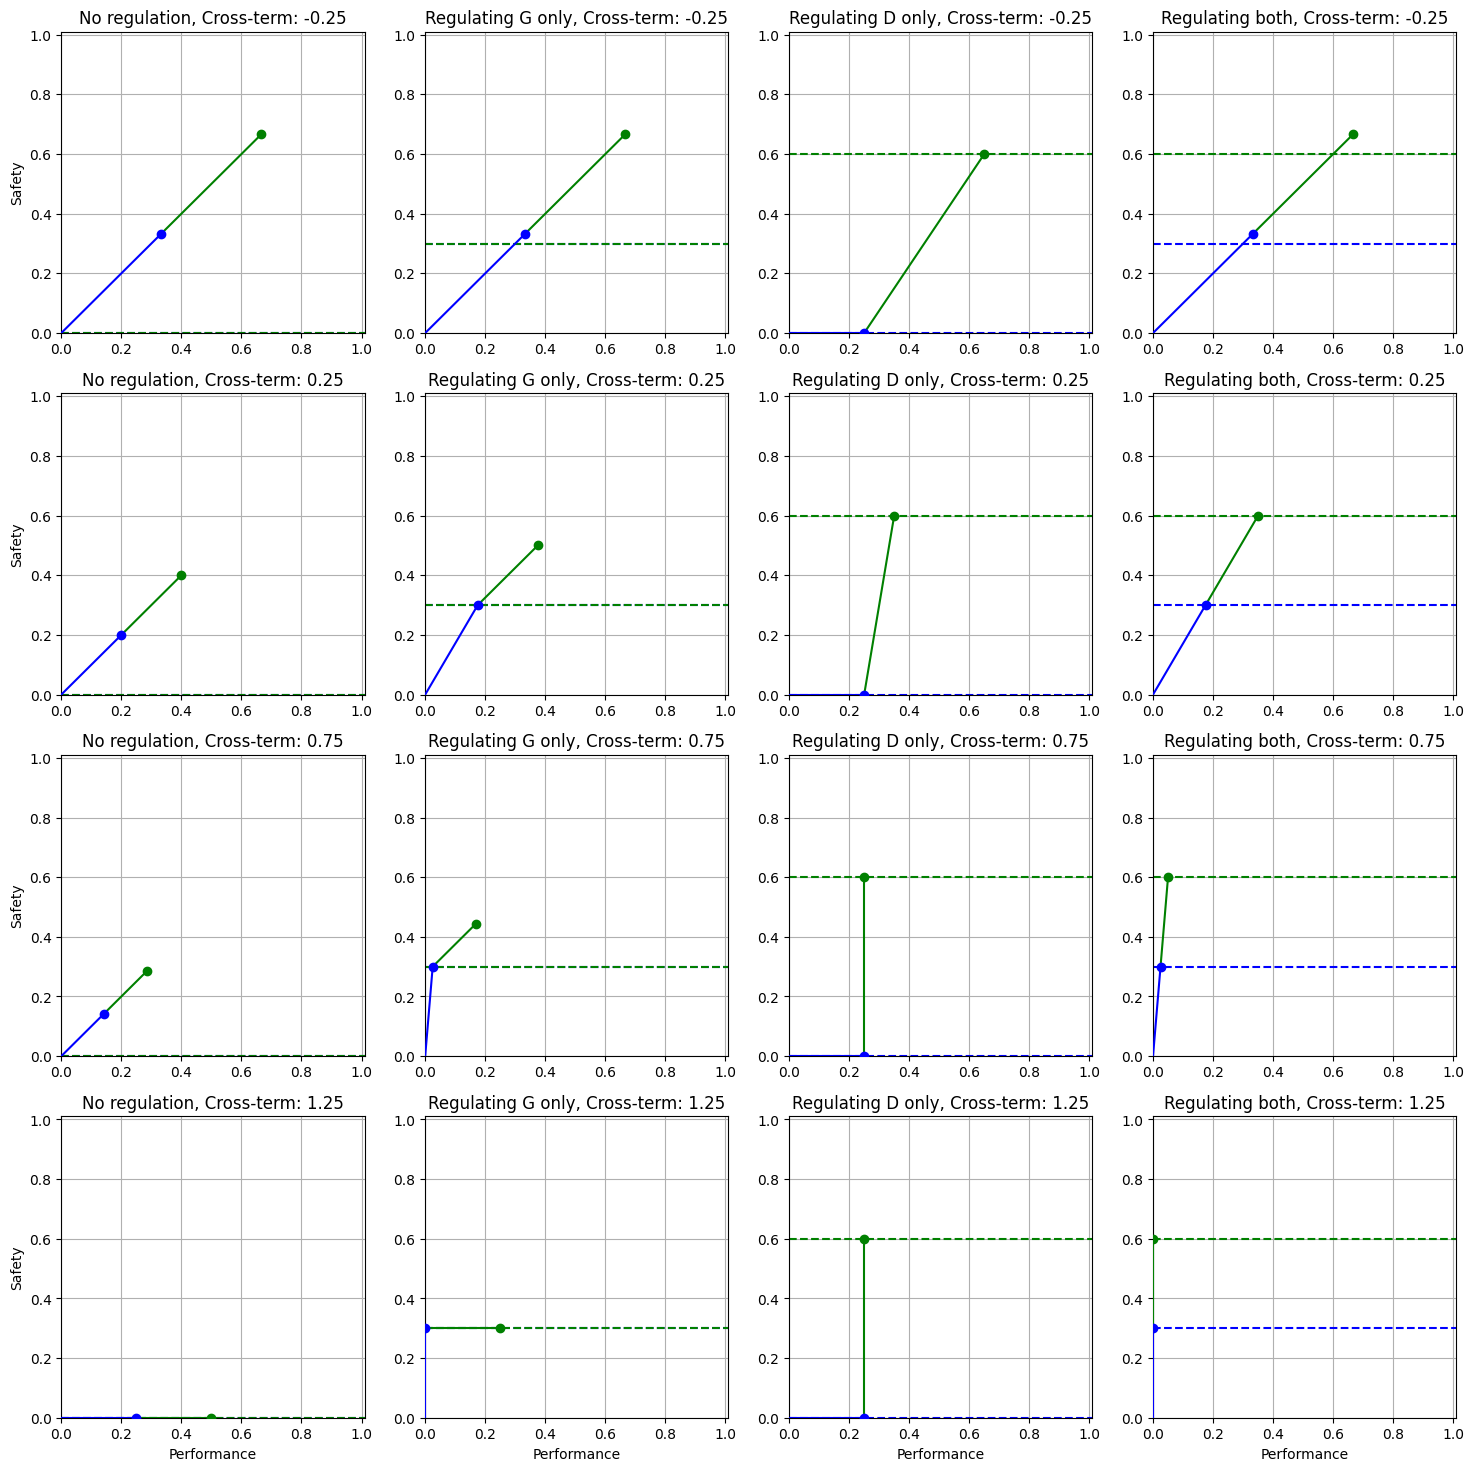

In [6]:
fig, ax = plt.subplots(len(reg_list_theta_G),len(reg_list_theta_G),figsize=[18,18])

index = 0
for c in range(len(crossterms)):
    print("c: ",c)
    for i in range(len(reg_list_theta_G)):
        ax[c,i].set_title("%s, Cross-term: %1.2f" %(df_crossterm_analysis_dac.loc[index,'regregime'],df_crossterm_analysis_dac.loc[index,'crossterm']))
        alpha_0 = df_crossterm_analysis_dac.loc[index,'alpha_0']
        beta_0 = df_crossterm_analysis_dac.loc[index,'beta_0']
        alpha_1 = df_crossterm_analysis_dac.loc[index,'alpha_1']
        beta_1 = df_crossterm_analysis_dac.loc[index,'beta_1']
        ax[c,i].plot([0,alpha_0],[0,beta_0],ls='-',c='b',zorder=10)
        ax[c,i].scatter(alpha_0,beta_0,c='b',zorder=100)
        ax[c,i].plot([alpha_0,alpha_1],[beta_0,beta_1],ls='-',c='g',zorder=10)
        ax[c,i].scatter(alpha_1,beta_1,c='g',zorder=100)

        ax[c,i].axhline(df_crossterm_analysis_dac.loc[index,'theta_G'],c='b',ls='--')
        ax[c,i].axhline(df_crossterm_analysis_dac.loc[index,'theta_D'],c='g',ls='--')
        ax[c,i].set_xlim([0,1.01])
        ax[c,i].set_ylim([0,1.01])
        ax[c,i].grid()
        #ax[c,i].set_xticks(np.linspace(0,3,31))
        #ax[c,i].set_yticks(np.linspace(0,3,31))
        if i==0:
            ax[c,i].set_ylabel('Safety')
        if c==3:
            ax[c,i].set_xlabel('Performance')
        index = index+1
        
#plt.savefig('multivariate_crossterm_divide_and_conquer_jun9.png',bbox_inches='tight',dpi=300)

        

In [50]:
regD=0.7
regG=0.4
reg_list_theta_G = [0,regG,0,regG]
reg_list_theta_D = [0,regG,regD,regD]
regregimes = ['No regulation','Regulating G only','Regulating D only','Regulating both']
#crossterms = [-0.25,0.25,0.75, 1.25]
crossterms = list(np.linspace(-0.5,.75,6)) + [1.25]# [-0.25,0,0.25,0.75, 1.25]
print(crossterms)
delta = 0.5
r = np.array([1,1])

df_crossterm_analysis_dac = pd.DataFrame(columns=['C_0','C_1','r','theta_G','theta_D', 'delta','crossterm','regregime'
                                              ,'alpha_0','beta_0','alpha_1','beta_1','UG','UD','Gstrategy','Dstrategy'
                                             ])
df_crossterm_analysis_dac['regregime']=[-1]*len(reg_list_theta_G)*len(crossterms)

index = 0
for c in crossterms:
    print("c: ",c)
    for i in range(len(reg_list_theta_G)):
        print("i: ",i)
        C_0 = np.array([[1-0.000001,c],[c,1]])
        C_1 = np.array([[1-0.000001,c],[c,1]])
        gamma_0, u_g0, stratGex = G_strategy(C_0,C_1,r,delta,reg_list_theta_D[i],reg_list_theta_G[i])
        gamma_1, u_d1, stratDex = D_strategy(gamma_0,C_1,r,delta,reg_list_theta_D[i])
        df_crossterm_analysis_dac.at[index,'C_0']=str(C_0)
        df_crossterm_analysis_dac.at[index,'C_1']=str(C_1)
        df_crossterm_analysis_dac.at[index,'crossterm']=float(c)
        df_crossterm_analysis_dac.at[index,'r']=str(r)
        df_crossterm_analysis_dac.at[index,'delta']=float(delta)
        df_crossterm_analysis_dac.at[index,'theta_D']=float(reg_list_theta_D[i])
        df_crossterm_analysis_dac.at[index,'theta_G']=float(reg_list_theta_G[i])
        df_crossterm_analysis_dac.at[index,'alpha_0']=float(gamma_0[0])
        df_crossterm_analysis_dac.at[index,'beta_0']=float(gamma_0[1])
        df_crossterm_analysis_dac.at[index,'alpha_1']=float(gamma_1[0])
        df_crossterm_analysis_dac.at[index,'beta_1']=float(gamma_1[1])
        df_crossterm_analysis_dac.at[index,'UG']=float(u_g0)
        df_crossterm_analysis_dac.at[index,'UD']=float(u_d1)
        df_crossterm_analysis_dac.at[index,'Gstrategy']=stratGex
        df_crossterm_analysis_dac.at[index,'Dstrategy']=stratDex
        df_crossterm_analysis_dac.at[index,'regregime']=str(regregimes[i])
        index= index + 1

[np.float64(-0.5), np.float64(-0.25), np.float64(0.0), np.float64(0.25), np.float64(0.5), np.float64(0.75), 1.25]
c:  -0.5
i:  0
i:  1


/var/folders/35/rbf5cr3s6wx53bzp489khqh40000gn/T/ipykernel_89768/3054965638.py:41: FutureWarning: Setting an item of incompatible dtype is deprecated and will raise an error in a future version of pandas. Value 'No regulation' has dtype incompatible with int64, please explicitly cast to a compatible dtype first.
  df_crossterm_analysis_dac.at[index,'regregime']=str(regregimes[i])


i:  2
i:  3
c:  -0.25
i:  0
i:  1
i:  2
i:  3
c:  0.0
i:  0
i:  1
i:  2
i:  3
c:  0.25
i:  0
i:  1
i:  2
i:  3
c:  0.5
i:  0
i:  1
i:  2
i:  3
c:  0.75
i:  0
i:  1
Strange case: 
[[0.999999 0.75    ]
 [0.75     1.      ]] [[0.999999 0.75    ]
 [0.75     1.      ]] [1 1] 0.5 0.4 0.4
Choice:  [0.  0.4] 0.18285718367356263 $\alpha_0=0$
All candidates:  [array([0. , 0.4]), array([0. , 0.4]), array([0. , 0.4])]
All utilities:  [np.float64(0.18285718367356263), np.float64(0.18285718367356263), np.float64(0.18285718367356263)]
All strategies:  ['$\\alpha_0=0$', '$\\beta_0=\\theta_G$', '$\\alpha_0=0,\\beta_0=\\theta_G$']
D response and utility:  (array([0.14285747, 0.5428569 ]), np.float64(0.27142859183678136), 'unconstrained')
i:  2
i:  3
Strange case: 
[[0.999999 0.75    ]
 [0.75     1.      ]] [[0.999999 0.75    ]
 [0.75     1.      ]] [1 1] 0.5 0.7 0.4
Choice:  [0.  0.4] 0.20250001250001248 $\alpha_0=0$
All candidates:  [array([0. , 0.4]), array([0. , 0.4]), array([0. , 0.4])]
All utilitie

/var/folders/35/rbf5cr3s6wx53bzp489khqh40000gn/T/ipykernel_89768/2423203444.py:22: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax[i].scatter(alpha_0,beta_0,c=color,alpha=1,s=40,zorder=100)
/var/folders/35/rbf5cr3s6wx53bzp489khqh40000gn/T/ipykernel_89768/2423203444.py:24: UserWarning: *c* argument looks like a single numeric RGB or RGBA sequence, which should be avoided as value-mapping will have precedence in case its length matches with *x* & *y*.  Please use the *color* keyword-argument or provide a 2D array with a single row if you intend to specify the same RGB or RGBA value for all points.
  ax[i].scatter(alpha_1,beta_1,c=color,alpha=1,s=40,zorder=100)


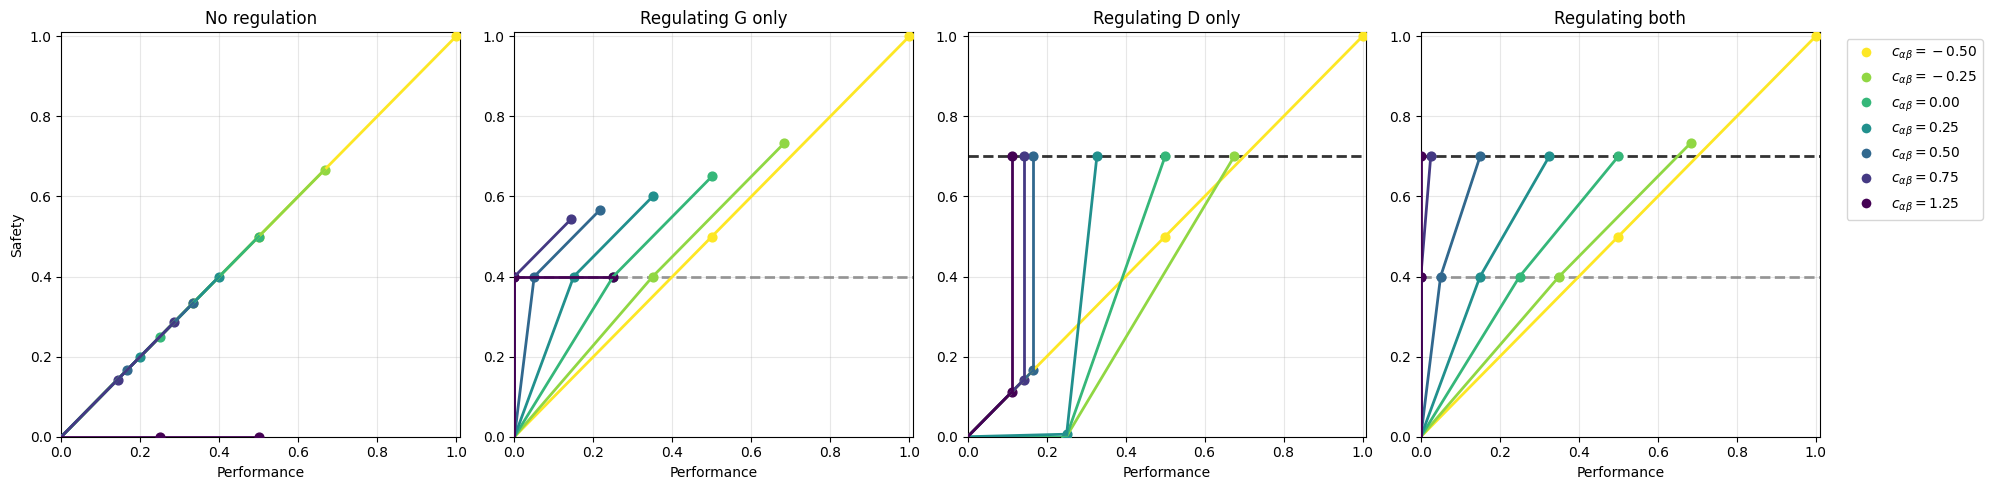

In [52]:
fig, ax = plt.subplots(1, len(reg_list_theta_G), figsize=[20, 5])

# Create a color map for different crossterms
colors = plt.cm.viridis_r(np.linspace(0, 1, len(crossterms)))

for i in range(len(reg_list_theta_G)):
    ax[i].set_title("%s" %(regregimes[i]))
    
    # Plot all crossterms for this regulation regime
    for c in range(len(crossterms)):
        index = c * len(reg_list_theta_G) + i
        
        alpha_0 = df_crossterm_analysis_dac.loc[index,'alpha_0']
        beta_0 = df_crossterm_analysis_dac.loc[index,'beta_0']
        alpha_1 = df_crossterm_analysis_dac.loc[index,'alpha_1']
        beta_1 = df_crossterm_analysis_dac.loc[index,'beta_1']
        
        # Use different colors for different crossterms
        color = colors[c]
        
        ax[i].plot([0,alpha_0],[0,beta_0],ls='-',c=color,alpha=1,zorder=200, linewidth=2)
        ax[i].scatter(alpha_0,beta_0,c=color,alpha=1,s=40,zorder=100)
        ax[i].plot([alpha_0,alpha_1],[beta_0,beta_1],ls='-',c=color,alpha=1,zorder=200, linewidth=2)
        ax[i].scatter(alpha_1,beta_1,c=color,alpha=1,s=40,zorder=100)

    # Add regulation thresholds
    if reg_list_theta_G[i] > 0:
        ax[i].axhline(reg_list_theta_G[i],c='gray',ls='--',alpha=0.8,linewidth=2)
    if reg_list_theta_D[i] > 0 and reg_list_theta_D[i] != reg_list_theta_G[i]:
        ax[i].axhline(reg_list_theta_D[i],c='black',ls='--',alpha=0.8,linewidth=2)
    
    ax[i].set_xlim([0,1.01])
    ax[i].set_ylim([0,1.01])
    ax[i].grid(alpha=0.3)
    ax[i].set_xlabel('Performance')
    if i==0:
        ax[i].set_ylabel('Safety')

    # Add legend for crossterms
    if i == len(reg_list_theta_G) - 1:  # Only add legend to the last subplot
        legend_elements = []
        for c in range(len(crossterms)):
            color = colors[c]
            legend_elements.append(plt.Line2D([0], [0], marker='o', color='w', 
                                            markerfacecolor=color, markersize=8, 
                                            label=f'$c_{{\\alpha\\beta}} = {crossterms[c]:.2f}$'))
        ax[i].legend(handles=legend_elements, bbox_to_anchor=(1.05, 1), loc='upper left')
    

plt.tight_layout()


In [124]:
np.round(np.linspace(-0.9,1.5,61),4)

array([-0.9 , -0.86, -0.82, -0.78, -0.74, -0.7 , -0.66, -0.62, -0.58,
       -0.54, -0.5 , -0.46, -0.42, -0.38, -0.34, -0.3 , -0.26, -0.22,
       -0.18, -0.14, -0.1 , -0.06, -0.02,  0.02,  0.06,  0.1 ,  0.14,
        0.18,  0.22,  0.26,  0.3 ,  0.34,  0.38,  0.42,  0.46,  0.5 ,
        0.54,  0.58,  0.62,  0.66,  0.7 ,  0.74,  0.78,  0.82,  0.86,
        0.9 ,  0.94,  0.98,  1.02,  1.06,  1.1 ,  1.14,  1.18,  1.22,
        1.26,  1.3 ,  1.34,  1.38,  1.42,  1.46,  1.5 ])

In [125]:
reg_list_theta_G = [0.4,0.4,0,0]
reg_list_theta_D = [.8,0,.8,0]
regregimes = ['both','G only','D only','no regulation']
crossterms = np.round(np.linspace(-0.9,1.5,61),4)#list(np.round(np.linspace(-0.9,0.9,19),4)) + [0.99,1.01] + list(np.round(np.linspace(1.1,1.5,4),4))
print(crossterms)
delta = 0.5
r = np.array([1,1])

df_crossterm_analysis = pd.DataFrame(columns=['C_0','C_1','r','theta_G','theta_D', 'delta','crossterm','regregime'
                                              ,'alpha_0','beta_0','alpha_1','beta_1','UG','UD','Gstrategy','Dstrategy'
                                             ])
df_crossterm_analysis['regregime']=[-1]*len(reg_list_theta_G)*len(crossterms)

index = 0
for c in crossterms:
    print("c: ",c)
    for i in range(len(reg_list_theta_G)):
        print("i: ",i)
        C_0 = np.array([[1-0.0000001,c],[c,1]])
        C_1 = np.array([[1-0.0000001,c],[c,1]])
        gamma_0, u_g0, stratGex = G_strategy(C_0,C_1,r,delta,reg_list_theta_D[i],reg_list_theta_G[i])
        gamma_1, u_d1, stratDex = D_strategy(gamma_0,C_1,r,delta,reg_list_theta_D[i])
        df_crossterm_analysis.at[index,'C_0']=str(C_0)
        df_crossterm_analysis.at[index,'C_1']=str(C_1)
        df_crossterm_analysis.at[index,'crossterm']=float(c)
        df_crossterm_analysis.at[index,'r']=str(r)
        df_crossterm_analysis.at[index,'delta']=float(delta)
        df_crossterm_analysis.at[index,'theta_D']=float(reg_list_theta_D[i])
        df_crossterm_analysis.at[index,'theta_G']=float(reg_list_theta_G[i])
        df_crossterm_analysis.at[index,'alpha_0']=float(gamma_0[0])
        df_crossterm_analysis.at[index,'beta_0']=float(gamma_0[1])
        df_crossterm_analysis.at[index,'alpha_1']=float(gamma_1[0])
        df_crossterm_analysis.at[index,'beta_1']=float(gamma_1[1])
        df_crossterm_analysis.at[index,'UG']=float(u_g0)
        df_crossterm_analysis.at[index,'UD']=float(u_d1)
        df_crossterm_analysis.at[index,'Gstrategy']=stratGex
        df_crossterm_analysis.at[index,'Dstrategy']=stratDex
        df_crossterm_analysis.at[index,'regregime']=str(regregimes[i])
        index= index + 1
    

[-0.9  -0.86 -0.82 -0.78 -0.74 -0.7  -0.66 -0.62 -0.58 -0.54 -0.5  -0.46
 -0.42 -0.38 -0.34 -0.3  -0.26 -0.22 -0.18 -0.14 -0.1  -0.06 -0.02  0.02
  0.06  0.1   0.14  0.18  0.22  0.26  0.3   0.34  0.38  0.42  0.46  0.5
  0.54  0.58  0.62  0.66  0.7   0.74  0.78  0.82  0.86  0.9   0.94  0.98
  1.02  1.06  1.1   1.14  1.18  1.22  1.26  1.3   1.34  1.38  1.42  1.46
  1.5 ]
c:  -0.9
i:  0
i:  1
i:  2
i:  3
c:  -0.86
i:  0
i:  1
i:  2
i:  3
c:  -0.82
i:  0
i:  1
i:  2
i:  3
c:  -0.78
i:  0
i:  1
i:  2
i:  3
c:  -0.74
i:  0
i:  1
i:  2
i:  3
c:  -0.7
i:  0
i:  1
i:  2
i:  3
c:  -0.66
i:  0
i:  1
i:  2
i:  3
c:  -0.62
i:  0
i:  1
i:  2
i:  3
c:  -0.58
i:  0
i:  1
i:  2
i:  3
c:  -0.54
i:  0
i:  1
i:  2
i:  3
c:  -0.5
i:  0
i:  1
i:  2
i:  3
c:  -0.46
i:  0
i:  1
i:  2
i:  3
c:  -0.42
i:  0
i:  1
i:  2
i:  3
c:  -0.38
i:  0
i:  1
i:  2
i:  3
c:  -0.34
i:  0
i:  1
i:  2
i:  3
c:  -0.3
i:  0
i:  1
i:  2
i:  3
c:  -0.26
i:  0
i:  1
i:  2
i:  3
c:  -0.22
i:  0
i:  1
i:  2
i:  3
c:  -0.18
i:  0
i:  

i:  3
c:  0.94
i:  0
Strange case: 
[[0.9999999 0.94     ]
 [0.94      1.       ]] [[0.9999999 0.94     ]
 [0.94      1.       ]] [1 1] 0.5 0.8 0.4
Choice:  [0.  0.4] 0.24 $\alpha_0=0$
All candidates:  [array([0. , 0.4]), array([0. , 0.4]), array([0. , 0.4])]
All utilities:  [0.24, 0.24, 0.24]
All strategies:  ['$\\alpha_0=0$', '$\\beta_0=\\theta_G$', '$\\alpha_0=0,\\beta_0=\\theta_G$']
D response and utility:  (array([0. , 0.8]), 0.24, 'constrained $\\alpha_1=\\alpha_0$')
i:  1
Strange case: 
[[0.9999999 0.94     ]
 [0.94      1.       ]] [[0.9999999 0.94     ]
 [0.94      1.       ]] [1 1] 0.5 0 0.4
Choice:  [0.  0.4] 0.16886598270273406 $\alpha_0=0$
All candidates:  [array([0. , 0.4]), array([0. , 0.4]), array([0. , 0.4])]
All utilities:  [0.16886598270273406, 0.16886598270273406, 0.16886598270273406]
All strategies:  ['$\\alpha_0=0$', '$\\beta_0=\\theta_G$', '$\\alpha_0=0,\\beta_0=\\theta_G$']
D response and utility:  (array([0.12886609, 0.52886588]), 0.26443299135136716, 'unconstr

Strange case: 
[[0.9999999 1.22     ]
 [1.22      1.       ]] [[0.9999999 1.22     ]
 [1.22      1.       ]] [1 1] 0.5 0.8 0.4
Choice:  [0.  0.4] 0.24 $\alpha_0=0$
All candidates:  [array([0. , 0.4]), array([0. , 0.4]), array([0. , 0.4])]
All utilities:  [0.24, 0.24, 0.24]
All strategies:  ['$\\alpha_0=0$', '$\\beta_0=\\theta_G$', '$\\alpha_0=0,\\beta_0=\\theta_G$']
D response and utility:  (array([0. , 0.8]), 0.24, 'constrained $\\alpha_1=\\alpha_0$')
i:  1
Strange case: 
[[0.9999999 1.22     ]
 [1.22      1.       ]] [[0.9999999 1.22     ]
 [1.22      1.       ]] [1 1] 0.5 0 0.4
Choice:  [0.  0.4] 0.16499999999999998 $\alpha_0=0$
All candidates:  [array([0. , 0.4]), array([0. , 0.4]), array([0. , 0.4])]
All utilities:  [0.16499999999999998, 0.16499999999999998, 0.16499999999999998]
All strategies:  ['$\\alpha_0=0$', '$\\beta_0=\\theta_G$', '$\\alpha_0=0,\\beta_0=\\theta_G$']
D response and utility:  (array([0.  , 0.65]), 0.2625, 'constrained $\\alpha_1=\\alpha_0$')
i:  2
i:  3
c:  1.

Strange case: 
[[0.9999999 1.42     ]
 [1.42      1.       ]] [[0.9999999 1.42     ]
 [1.42      1.       ]] [1 1] 0.5 0.8 0
Choice:  [0.   0.25] 0.3375 $\alpha_0=0$
All candidates:  [array([0.  , 0.25]), array([1.00000000e-06, 4.50729094e-01]), array([1.00000000e-06, 4.50729094e-01])]
All utilities:  [0.3375, 0.19684250358570923, 0.19684250358570923]
All strategies:  ['$\\alpha_0=0$', '$U_D=0, \\alpha_0=0$', '$U_D=0, \\alpha_0=0$']
D response and utility:  (array([1.e-06, 8.e-01]), 0.27801033434948996, 'constrained $\\alpha_1=\\alpha_0$')
i:  3
c:  1.46
i:  0
Strange case: 
[[0.9999999 1.46     ]
 [1.46      1.       ]] [[0.9999999 1.46     ]
 [1.46      1.       ]] [1 1] 0.5 0.8 0.4
Choice:  [0.  0.4] 0.24 $\alpha_0=0$
All candidates:  [array([0. , 0.4]), array([0. , 0.4]), array([1.0000000e-06, 4.7744889e-01]), array([1.0000000e-06, 4.7744889e-01]), array([0. , 0.4])]
All utilities:  [0.24, 0.24, 0.17204166334405666, 0.17204166334405666, 0.24]
All strategies:  ['$\\alpha_0=0$', '$\\

In [126]:
c=0.0328
C_0 = np.array([[1-0.0000001,c],[c,1]])
C_1 = np.array([[1-0.0000001,c],[c,1]])

gamma_0, u_g0, stratGex = G_strategy(C_0,C_1,r,delta,0.8,0)
gamma_1, u_d1, stratDex = D_strategy(gamma_0,C_1,r,delta,0.8)

print(gamma_0, u_g0, stratGex)
print(gamma_1, u_d1, stratDex)

[0.3798639147862916, 1e-06] 0.5575153807339681 $U_D=0, \beta_0=\theta_G$
[0.60362397 0.8       ] 2.1146776585379e-06 constrained $\beta_1=max(\beta_0,\theta)$


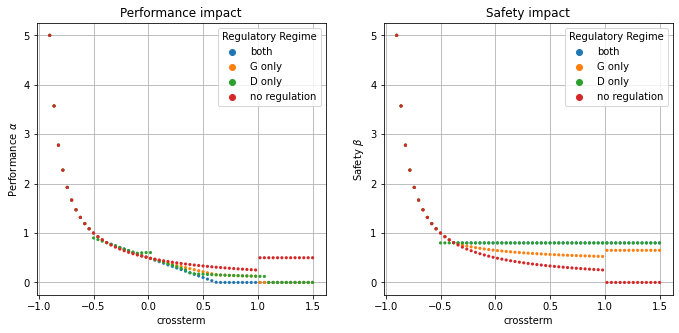

In [128]:
df_crossterm_analysis['Regulatory Regime'] = df_crossterm_analysis['regregime']
fix,ax = plt.subplots(1,2,figsize=[11.4,5])

#sns.scatterplot(data=df_crossterm_analysis,x='crossterm',y='alpha_0',hue='Regulatory Regime',linewidth=0,ax=ax[0],s=10)
#sns.scatterplot(data=df_crossterm_analysis[df_crossterm_analysis['regregime']=='D only'],x='crossterm',y='alpha_0',linewidth=0,ax=ax[0],color='black',s=10,zorder=100)
sns.scatterplot(data=df_crossterm_analysis,x='crossterm',y='alpha_1',hue='Regulatory Regime',linewidth=0,s=10
             ,ax=ax[0],zorder=10)
ax[0].grid()
ax[0].set_title("Performance impact")

#ax[0].set_xlim([-0.875,1.6])
#ax[0].set_ylim([-0.1,3])
ax[0].set_ylabel('Performance $\\alpha$')

#sns.lineplot(data=df_crossterm_analysis[df_crossterm_analysis['regregime']=='both'],x='crossterm',y='beta_1',hue='Regulatory Regime',linewidth=0,ax=ax[1],s=60,zorder=10)
#sns.scatterplot(data=df_crossterm_analysis[df_crossterm_analysis['regregime']=='D only'],x='crossterm',y='beta_0',ax=ax[1],linewidth=0,color='black',s=10,zorder=100)
sns.scatterplot(data=df_crossterm_analysis,x='crossterm',y='beta_1',hue='Regulatory Regime',ax=ax[1],linewidth=0,s=10
             ,zorder=10)
ax[1].grid()
ax[1].set_title("Safety impact")
#ax[1].set_xlim([-0.875,1.6])
#ax[1].set_ylim([-0.1,3])
ax[1].set_ylabel('Safety $\\beta$')


plt.savefig('multivariate_crossterm_regulation_effects_feb.png',bbox_inches='tight',dpi=200)
